[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter16_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 16: Review

*Lecture notebook: the course in one notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Three series, one common window (2 January 2015 to 18 September 2026): the S&P 500, the BET and Bitcoin.
- One section per block of chapters: returns and performance (Chapters 0–1), distribution and tails (2–6), dependence and efficiency (7–8), GARCH (9), VaR, ES and backtesting (10), long memory (11).
- Every function uses the definition of its chapter; the last cell prints the course in one table.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed.; Cont (2001); Lo and MacKinlay (1988); Bollerslev (1986); Kupiec (1995); Hurst (1951).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %, each series on its own calendar (Bitcoin: 7 days a week); annualisation with the actual number of observations per year $q$.
- VaR at level $\alpha$: $\mathrm{VaR}_\alpha = -q_\alpha$, the loss exceeded with probability $\alpha$ (VaR 1%); ES 2.5%: the average loss on the worst 2.5% of days. Both are positive numbers.

In [6]:
from arch import arch_model
NAME = {'sp500': 'S&P 500', 'bet': 'BET', 'btc': 'Bitcoin'}
ASSETS = ['sp500', 'bet', 'btc']
COLORS = {'sp500': '#1A3A6E', 'bet': '#CD0000', 'btc': '#B5853F'}
START = '2015-01-01'
LB_LAGS = 10
VR_Q = 5
HILL_FRAC = 0.025
LAMBDA = 0.94
ALPHA_VAR = 0.01
ALPHA_ES = 0.025
WINDOW = 500
OOS_START = '2017-01-01'
NMIN = 10


def returns(k, start=START, end=END):
    """Daily log returns in % on the series' own calendar (Bitcoin: 7 days a week)."""
    return log_returns(k, start, end)


def performance(k, start=START, end=END, rf=0.0):
    """Annualised mean log return and volatility with the actual frequency q, CAGR, Sharpe ratio (arithmetic mean,
    risk-free rate rf in % a year), maximum drawdown MDD = min_t (P_t / max_{s<=t} P_s - 1)."""
    p = load_close(k, start, end)
    r = 100 * np.log(p).diff().dropna()
    R = 100 * p.pct_change().dropna()
    q = periods_per_year(r)
    years = (p.index[-1] - p.index[0]).days / 365.25
    dd = p / p.cummax() - 1
    mean_ar = q * R.mean()
    vol = np.sqrt(q) * r.std()
    return {'n': int(len(r)), 'q': float(q), 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
            'mean_log': float(q * r.mean()), 'mean_arith': float(mean_ar), 'vol': float(vol),
            'cagr': float(100 * ((p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1)),
            'sharpe': float((mean_ar - rf) / vol), 'sharpe_se': float(np.sqrt((1 + ((mean_ar - rf) / vol) ** 2 / 2) / years)),
            'mdd': float(100 * dd.min()), 'mdd_date': dd.idxmin().date().isoformat(),
            'peak_date': p.loc[:dd.idxmin()].idxmax().date().isoformat(), 'growth': float(p.iloc[-1] / p.iloc[0])}


def moments(r):
    """Skewness S = m3 / m2^(3/2), excess kurtosis K = m4 / m2^2 - 3, Jarque-Bera JB = n/6 (S^2 + K^2/4) ~ chi2(2)."""
    x = np.asarray(r, float)
    e = x - x.mean()
    m2, m3, m4 = (np.mean(e ** j) for j in (2, 3, 4))
    S, K = m3 / m2 ** 1.5, m4 / m2 ** 2 - 3
    jb = len(x) / 6 * (S ** 2 + K ** 2 / 4)
    return {'skew': float(S), 'exkurt': float(K), 'jb': float(jb), 'p_jb': float(stats.chi2.sf(jb, 2))}


def hill(x, k):
    """Hill (1975): alpha_hat = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^(-1), X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x, float))[::-1]
    return float(1.0 / np.mean(np.log(x[:k] / x[k])))


def tail_index(r, frac=HILL_FRAC):
    """Hill tail index of the losses L = -r with k = frac * n, and its i.i.d. standard error alpha / sqrt(k)."""
    L = -np.asarray(r, float)
    k = int(round(frac * len(L)))
    a = hill(L[L > 0], k)
    return {'k': k, 'alpha': a, 'se': a / np.sqrt(k)}


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, m=LB_LAGS):
    """Ljung-Box Q(m) = T(T+2) sum_{k=1..m} rho_k^2 / (T-k) ~ chi2(m) under no autocorrelation."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return {'q': float(q), 'p': float(stats.chi2.sf(q, m)), 'crit': float(stats.chi2.ppf(0.95, m)), 'rho1': float(rho[0])}


def variance_ratio(x, q=VR_Q):
    """Lo and MacKinlay (1988): overlapping VR(q) with bias corrections, the i.i.d. statistic Z(q) and the
    heteroskedasticity-robust Z*(q) = (VR - 1) / sqrt(theta / T), theta = sum_{j<q} [2(q-j)/q]^2 delta_hat(j)."""
    x = np.asarray(x, float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = np.sum(e ** 2) / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu
    var_c = np.sum(agg ** 2) / (q * (T - q + 1) * (1 - q / T))
    vr = var_c / var_a
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = np.sum(e ** 2) ** 2
    theta = sum((2 * (q - j) / q) ** 2 * T * np.sum(e[j:] ** 2 * e[:-j] ** 2) / den for j in range(1, q))
    zs = (vr - 1) / np.sqrt(theta / T)
    return {'q': q, 'vr': float(vr), 'z': float(z), 'zs': float(zs), 'p_zs': float(2 * stats.norm.sf(abs(zs)))}


def ewma_var(r, lam=LAMBDA):
    """EWMA (RiskMetrics) variance sigma_t^2 = lam sigma_{t-1}^2 + (1 - lam) r_{t-1}^2, started at the variance of the
    first 30 returns; the value at t uses returns up to t-1 only."""
    x = np.asarray(r, float)
    s2 = np.empty(len(x))
    s2[0] = np.var(x[:30])
    for t in range(1, len(x)):
        s2[t] = lam * s2[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s2, index=r.index)


def garch_t(r):
    """GARCH(1,1) with constant mean and standardised Student-t innovations (maximum likelihood, arch package):
    persistence alpha + beta and half-life ln 0.5 / ln(alpha + beta) in days (None when alpha + beta is 1 to four
    decimals: an integrated GARCH, IGARCH)."""
    res = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off', options={'maxiter': 2000})
    p = res.params
    pers = float(p['alpha[1]'] + p['beta[1]'])
    return {'mu': float(p['mu']), 'omega': float(p['omega']), 'alpha': float(p['alpha[1]']), 'beta': float(p['beta[1]']),
            'nu': float(p['nu']), 'pers': pers, 'half_life': float(np.log(0.5) / np.log(pers)) if pers < 0.9999 else None}


def hs_var(x, a=ALPHA_VAR):
    """Historical simulation: VaR_a = -r_(k), k = ceil(n a), the k-th smallest return."""
    x = np.sort(np.asarray(x, float))
    return float(-x[int(np.ceil(len(x) * a - 1e-9)) - 1])


def hs_es(x, a=ALPHA_ES):
    """Historical simulation: ES_a = minus the mean of the k = ceil(n a) smallest returns."""
    x = np.sort(np.asarray(x, float))
    return float(-x[:int(np.ceil(len(x) * a - 1e-9))].mean())


def normal_var(x, a=ALPHA_VAR):
    """Normal VaR_a = -(mu + sigma z_a)."""
    return float(-(np.mean(x) + np.std(x, ddof=1) * stats.norm.ppf(a)))


def normal_es(x, a=ALPHA_ES):
    """Normal ES_a = -mu + sigma phi(z_a) / a."""
    return float(-np.mean(x) + np.std(x, ddof=1) * stats.norm.pdf(stats.norm.ppf(a)) / a)


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec (1995): LR_uc = -2 ln[(1-a)^(n-x) a^x / ((1-x/n)^(n-x) (x/n)^x)] ~ chi2(1)."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = ((n - x) * np.log(1 - ph) if ph < 1 else 0.0) + (x * np.log(ph) if x > 0 else 0.0)
    lr = float(-2 * (l0 - l1))
    return {'x': int(x), 'n': int(n), 'rate': float(100 * ph), 'lr': lr, 'p': float(stats.chi2.sf(lr, 1))}


def var_backtest(k, start=OOS_START, window=WINDOW, a=ALPHA_VAR):
    """One-day VaR 1% forecasts from `start`: historical simulation on the last `window` returns and EWMA-Normal
    (-sigma_t z_a, lambda = 0.94); exceptions r_t < -VaR_t, Kupiec test, most exceptions in 250 days."""
    r = log_returns(k, None, END)
    s2 = ewma_var(r)
    hs = (-r.rolling(window).quantile(a, interpolation='lower')).shift(1)
    ew = -np.sqrt(s2) * stats.norm.ppf(a)
    df = pd.DataFrame({'r': r, 'HS': hs, 'EWMA': ew}).loc[start:].dropna()
    out = {'n': int(len(df)), 'first': df.index[0].date().isoformat()}
    for m in ('HS', 'EWMA'):
        hit = (df['r'] < -df[m]).astype(int)
        out[m] = kupiec(int(hit.sum()), len(df), a)
        out[m]['max250'] = int(hit.rolling(250).sum().max())
        out[m]['mean_var'] = float(df[m].mean())
    return out, df


def block_sizes(N, nmin=NMIN, num=20):
    """About `num` block sizes spaced evenly on a log scale between nmin and N/4."""
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(N // 4), num)).astype(int))


def hurst_rs(x):
    """Hurst exponent: slope of log10 of the average R/S of the non-overlapping blocks of size n on log10 n."""
    x = np.asarray(x, float)
    sizes, out = block_sizes(len(x)), []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R, S = Y.max(axis=1) - Y.min(axis=1), X.std(axis=1)
        out.append(np.mean(R[S > 0] / S[S > 0]))
    return float(np.polyfit(np.log10(sizes), np.log10(out), 1)[0])

## 1. Returns and performance (Chapters 0–1)

- CAGR, annualised mean and volatility, the Sharpe ratio with its standard error, the maximum drawdown.

In [7]:
perf = {NAME[k]: performance(k) for k in ASSETS}
pd.DataFrame(perf).T[['n', 'q', 'mean_log', 'mean_arith', 'cagr', 'vol', 'sharpe', 'sharpe_se', 'mdd', 'mdd_date']]

,n,q,mean_log,mean_arith,cagr,vol,sharpe,sharpe_se,mdd,mdd_date
S&P 500,2943,251.504621,11.220193,12.784071,11.86507,17.689835,0.722679,0.328175,-33.92496,2020-03-23
BET,2925,250.024865,13.226993,14.43293,14.138105,15.540961,0.928703,0.349731,-31.124049,2020-03-23
Bitcoin,4278,365.335399,47.403092,69.532188,60.627867,66.680182,1.042771,0.36304,-83.399009,2018-12-15


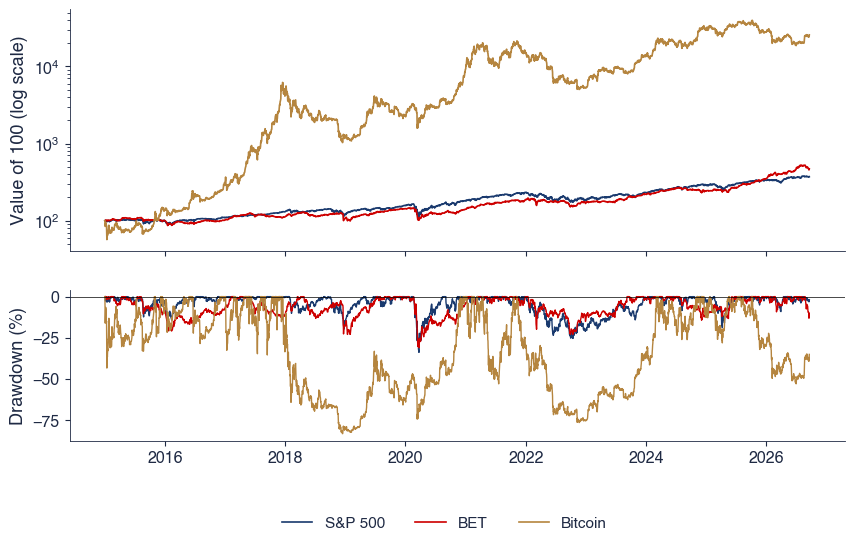

In [8]:
def fig_three_series(save=True):
    """Growth of 100 invested on 2 January 2015 (log scale) and the drawdown of each series."""
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, gridspec_kw={'height_ratios': [1.6, 1]})
    for k in ASSETS:
        p = load_close(k, START, END)
        a1.plot(p.index, 100 * p / p.iloc[0], color=COLORS[k], lw=1.2, label=NAME[k])
        a2.plot(p.index, 100 * (p / p.cummax() - 1), color=COLORS[k], lw=1.0)
    a1.set_yscale('log')
    a1.set_ylabel('Value of 100 (log scale)')
    a2.set_ylabel('Drawdown (%)')
    a2.axhline(0, color='black', lw=0.5)
    h, l = a1.get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch16_three_series')
    else:
        plt.show()


fig_three_series(save=False)

- Bitcoin: the arithmetic mean is far above the CAGR, the volatility drag $\approx \sigma^2/2$.
- The Sharpe ratios differ by less than their standard errors.

## 2. Distribution and tails (Chapters 2–6)

- Skewness, excess kurtosis and Jarque–Bera; the Hill tail index of the losses with $k = 2.5\%$ of $n$.

In [9]:
pd.DataFrame({NAME[k]: {**moments(returns(k)), **{'hill_' + c: v for c, v in tail_index(returns(k)).items()}} for k in ASSETS}).T.round(3)

,skew,exkurt,jb,p_jb,hill_k,hill_alpha,hill_se
S&P 500,-0.644,15.849,31004.891,0.0,74.0,2.753,0.320
BET,-1.414,17.847,39794.031,0.0,73.0,2.194,0.257
Bitcoin,-0.731,12.167,26770.367,0.0,107.0,2.670,0.258


- Excess kurtosis above 10 and tail indices between 2 and 3: heavy tails, finite variance, infinite kurtosis.

## 3. Dependence and efficiency (Chapters 7–8)

- Autocorrelation of $r_t$ and $|r_t|$; Ljung–Box $Q(10)$ on $r_t$ and $r_t^2$; the robust variance ratio $Z^*(5)$.

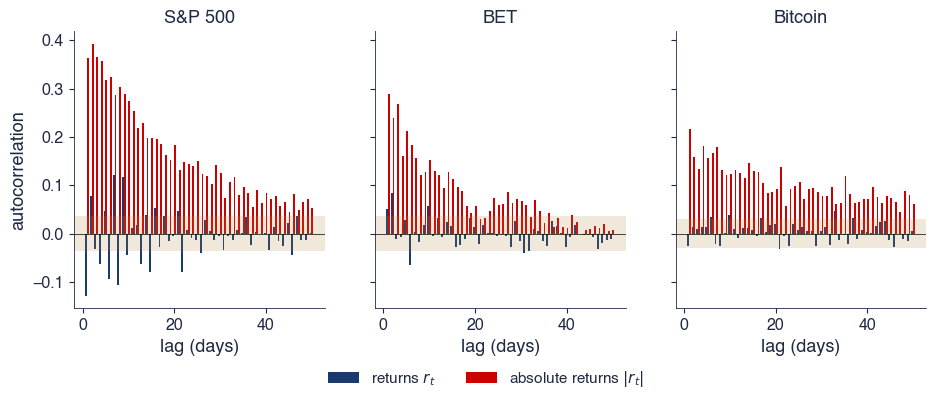

In [10]:
def fig_stylised(lags=50, save=True):
    """ACF of daily returns and of absolute returns, lags 1-50, with the 95% band +-1.96/sqrt(T)."""
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
    for ax, k in zip(axes, ASSETS):
        r = returns(k)
        band = 1.96 / np.sqrt(len(r))
        lg = np.arange(1, lags + 1)
        ax.bar(lg - 0.2, acf(r, lags), width=0.4, color='#1A3A6E', label='returns $r_t$')
        ax.bar(lg + 0.2, acf(np.abs(r), lags), width=0.4, color='#CD0000', label='absolute returns $|r_t|$')
        ax.axhspan(-band, band, color='#B5853F', alpha=0.18, lw=0)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(NAME[k])
        ax.set_xlabel('lag (days)')
    axes[0].set_ylabel('autocorrelation')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch16_stylised')
    else:
        plt.show()


fig_stylised(save=False)

In [11]:
pd.DataFrame({NAME[k]: {'LB r': ljung_box(returns(k))['q'], 'LB r^2': ljung_box(returns(k) ** 2)['q'],
                         'VR(5)': variance_ratio(returns(k))['vr'], 'Z*(5)': variance_ratio(returns(k))['zs'],
                         'p(Z*)': variance_ratio(returns(k))['p_zs']} for k in ASSETS}).T.round(3)

,LB r,LB r^2,VR(5),Z*(5),p(Z*)
S&P 500,236.419,3165.908,0.840,-1.336,0.181
BET,54.658,700.582,1.172,1.927,0.054
Bitcoin,21.355,210.751,0.988,-0.223,0.823


- The squared returns are far more autocorrelated than the returns: volatility clustering.
- The robust VR test does not reject the random walk at 5% on this window.

## 4. GARCH(1,1) with Student-t innovations (Chapter 9)

In [12]:
pd.DataFrame({NAME[k]: garch_t(returns(k)) for k in ASSETS}).T

,mu,omega,alpha,beta,nu,pers,half_life
S&P 500,0.092170,0.022178,0.164461,0.828368,5.499530,0.992828,96.302193
BET,0.086933,0.069071,0.184605,0.740059,5.010110,0.924664,8.849645
Bitcoin,0.115134,0.186888,0.106119,0.893881,3.156884,1.000000,NaN


- Persistence $\alpha + \beta$ close to 1; Bitcoin is an integrated GARCH (no finite half-life).

## 5. VaR, ES and backtesting (Chapter 10)

- VaR 1% and ES 2.5% by historical simulation and with the Normal distribution; one-day VaR 1% forecasts since 2017 by historical simulation (500 days) and EWMA-Normal, with the Kupiec test.

In [13]:
pd.DataFrame({NAME[k]: {'VaR 1% HS': hs_var(returns(k)), 'VaR 1% Normal': normal_var(returns(k)),
                         'ES 2.5% HS': hs_es(returns(k)), 'ES 2.5% Normal': normal_es(returns(k))} for k in ASSETS}).T.round(2)

,VaR 1% HS,VaR 1% Normal,ES 2.5% HS,ES 2.5% Normal
S&P 500,3.29,2.55,3.53,2.56
BET,2.72,2.23,3.21,2.24
Bitcoin,10.60,7.99,10.93,8.03


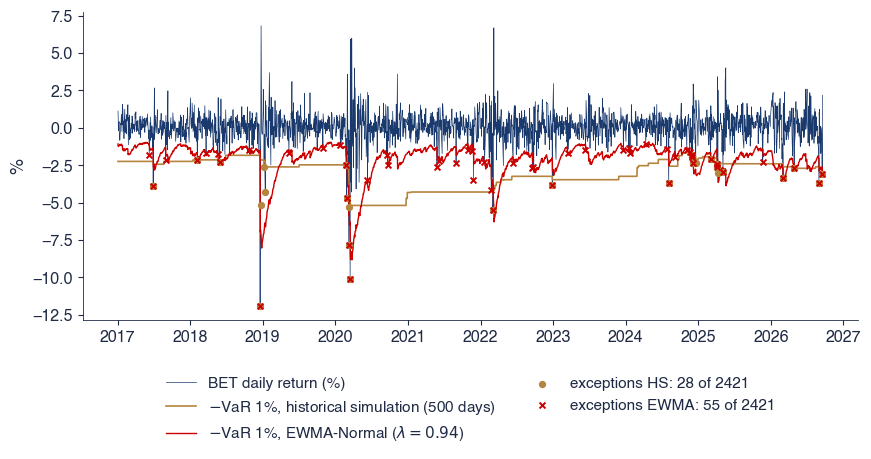

{'n': 2421,
 'first': '2017-01-03',
 'HS': {'x': 28,
  'n': 2421,
  'rate': 1.1565468814539448,
  'lr': 0.570565615397868,
  'p': 0.4500342434092056,
  'max250': 10,
  'mean_var': 3.0166389037389405},
 'EWMA': {'x': 55,
  'n': 2421,
  'rate': 2.271788517141677,
  'lr': 29.079659354338673,
  'p': 6.946247201366898e-08,
  'max250': 12,
  'mean_var': 2.0678908382354937}}

In [14]:
def fig_backtest(k='bet', save=True):
    """Daily returns since 2017 with minus the one-day VaR 1% of historical simulation (500 days) and EWMA-Normal;
    exceptions marked."""
    bt, df = var_backtest(k)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(df.index, df['r'], color='#1A3A6E', lw=0.5, label=f'{NAME[k]} daily return (%)')
    ax.plot(df.index, -df['HS'], color='#B5853F', lw=1.2, label='$-$VaR 1%, historical simulation (500 days)')
    ax.plot(df.index, -df['EWMA'], color='#CD0000', lw=1.0, label='$-$VaR 1%, EWMA-Normal ($\\lambda = 0.94$)')
    for m, c, mk in (('HS', '#B5853F', 'o'), ('EWMA', '#CD0000', 'x')):
        h = df[df['r'] < -df[m]]
        ax.scatter(h.index, h['r'], color=c, marker=mk, s=18, zorder=3,
                   label=f"exceptions {'HS' if m == 'HS' else 'EWMA'}: {bt[m]['x']} of {bt['n']}")
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch16_backtest')
    else:
        plt.show()
    return bt


bt = fig_backtest('bet', save=False)
bt

- EWMA-Normal follows the storms but has more than twice the target rate of exceptions: the Normal quantile is too small.
- Historical simulation has the right rate but reacts slowly: its exceptions come in clusters.

## 6. Long memory (Chapter 11)

In [15]:
pd.DataFrame({NAME[k]: {'H (R/S) of r': hurst_rs(returns(k)), 'H (R/S) of |r|': hurst_rs(np.abs(returns(k)))} for k in ASSETS}).T.round(3)

,H (R/S) of r,H (R/S) of |r|
S&P 500,0.534,0.842
BET,0.593,0.753
Bitcoin,0.586,0.779


- $H$ of $|r_t|$ is far above 0.5: the long memory is in the volatility, not in the returns.

## 7. The course in one table

In [16]:
def summary(k):
    """All key numbers of one series on the common window."""
    r = returns(k)
    out = {'perf': performance(k), 'mom': moments(r), 'hill': tail_index(r), 'lb_r': ljung_box(r),
           'lb_r2': ljung_box(r ** 2), 'acf1_abs': float(acf(np.abs(r), 1)[0]), 'vr': variance_ratio(r),
           'garch': garch_t(r), 'var_hs': hs_var(r), 'var_n': normal_var(r), 'es_hs': hs_es(r), 'es_n': normal_es(r),
           'H_r': hurst_rs(r), 'H_abs': hurst_rs(np.abs(r))}
    out['ewma_half'] = float(np.log(0.5) / np.log(LAMBDA))
    out['gap_n'] = float(100 * (1 - out['var_n'] / out['var_hs']))
    return out


def summary_table(S):
    """The course in one table (rows: quantities, columns: series)."""
    rows = {}
    for k in ASSETS:
        s = S[k]
        rows[NAME[k]] = {
            'observations': s['perf']['n'], 'obs per year': s['perf']['q'], 'mean log return % p.a.': s['perf']['mean_log'],
            'volatility % p.a.': s['perf']['vol'], 'Sharpe (rf = 0)': s['perf']['sharpe'], 'MDD %': s['perf']['mdd'],
            'skewness': s['mom']['skew'], 'excess kurtosis': s['mom']['exkurt'], 'Jarque-Bera': s['mom']['jb'],
            'Hill alpha (k = 2.5%)': s['hill']['alpha'], 'Ljung-Box r (10)': s['lb_r']['q'],
            'Ljung-Box r^2 (10)': s['lb_r2']['q'], 'VR(5)': s['vr']['vr'], 'Z*(5)': s['vr']['zs'],
            'GARCH alpha + beta': s['garch']['pers'], 'VaR 1% HS': s['var_hs'], 'VaR 1% Normal': s['var_n'],
            'ES 2.5% HS': s['es_hs'], 'Hurst R/S r': s['H_r'], 'Hurst R/S |r|': s['H_abs']}
    return pd.DataFrame(rows)


S = {k: summary(k) for k in ASSETS}
summary_table(S).round(3)

,S&P 500,BET,Bitcoin
observations,2943.000,2925.000,4278.000
obs per year,251.505,250.025,365.335
mean log return % p.a.,11.220,13.227,47.403
volatility % p.a.,17.690,15.541,66.680
Sharpe (rf = 0),0.723,0.929,1.043
MDD %,-33.925,-31.124,-83.399
skewness,-0.644,-1.414,-0.731
excess kurtosis,15.849,17.847,12.167
Jarque-Bera,31004.891,39794.031,26770.367
Hill alpha (k = 2.5%),2.753,2.194,2.670
